In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mohammedsulthan07","key":"b59c0c4839ed2a6652512c7bea00e24b"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
  0% 0.00/66.0M [00:00<?, ?B/s]
100% 66.0M/66.0M [00:00<00:00, 1.72GB/s]


In [8]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [9]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['normAmount'] = scaler.fit_transform(df[['Amount']])

df = df.drop(['Time','Amount'], axis=1)

In [12]:
fraud = df[df.Class == 1]
normal = df[df.Class == 0].sample(len(fraud), random_state=42)

df_balanced = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

df_balanced['Class'].value_counts()

,count
Class,
0,492
1,492


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df_balanced.drop('Class', axis=1)
y = df_balanced['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42)

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9289340101522843
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        87
           1       0.97      0.90      0.93       110

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197



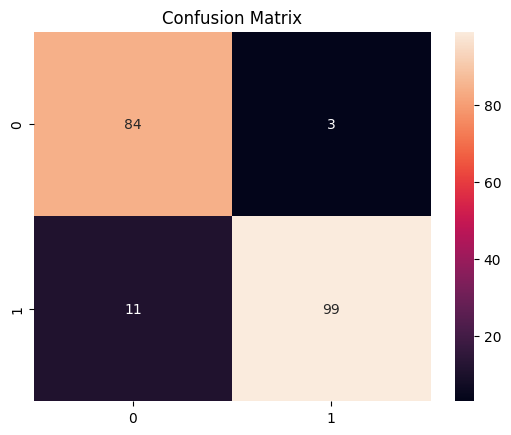

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

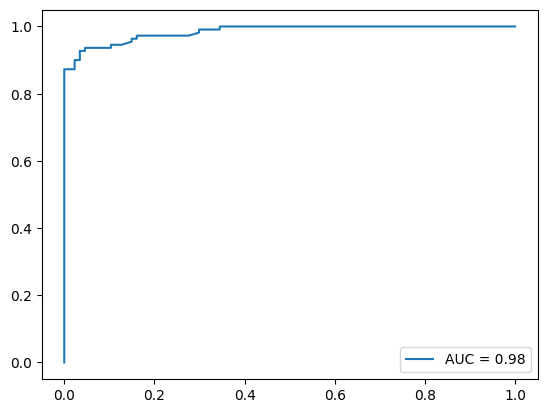

In [16]:
from sklearn.metrics import roc_curve, auc

prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.legend()
plt.show()

In [17]:
import joblib

joblib.dump(model, "fraud_model.pkl")

['fraud_model.pkl']

In [18]:
files.download("fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import numpy as np

sample = X_test.iloc[0:1]

prediction = model.predict(sample)
probability = model.predict_proba(sample)[0][1]

print("Prediction:", "Fraud" if prediction[0]==1 else "Normal")
print("Fraud Probability:", probability)

Prediction: Normal
Fraud Probability: 0.48
